# Assignment 5: Data Visualization
```
Course: ENV 700 - Environmental Data Exploration
Author: Ziyan Wang
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Visualization**, the third/fourth stage in the data analytics pipeline: **exploration, wrangling, analysis, and visualization**.

In this notebook, you will be working with two datasets: the Peter/Paul Northern Lakes Chemistry & Nutrients processed dataset, and the NEON Niwot Litter Mass Trap dataset. Specifically, we will be visualizing various aspects and relationships among the variable in these datasets. 

As always, address the tasks below to the best of your ability. Be sure to ask if any question is ambigious or unclear. When complete. Export your notebook into an HTML formatted document. Also, stage, commit, and push your assignment to your GitHub repository. 

#### 1. Setup
* 1.1 Import the Path, Pandas, Seaborn, and Calendar packages into your notebook
* 1.2 Set path objects for your project folder, the raw data folder, and the `Processed_Key` folder

In [8]:
# 1.1 Packages
from pathlib import Path
import calendar
import pandas as pd
import seaborn as sns

In [16]:
# 1.2 Paths 
project_fldr = Path("..")
raw_fldr = project_fldr / 'data' / 'raw'
processed_fldr = project_fldr / 'data' / 'processed'

print('Project:', project_fldr)
print('Raw data:', raw_fldr)
print('Processed data:', processed_fldr)

Project: ..
Raw data: ..\data\raw
Processed data: ..\data\processed


#### 2. Ingest Data & Wrangle
* 2.1 NTL LTER data for Peter and Paul Lakes
    - Read the `'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv'` file into a dataframe. 
    - Convert the `sampledate` column to a datetime object.
    - Create a `month_abb` column to be an ordered categorical data type with levels for all months.
    - Display the first 5 records of the dataframe
* 2.2 NEON NIWO Litter Mass Trap Data (processed)
    - Read in the `NEON_NIWO_Litter_mass_trap_Processed.csv` file into a dataframe.
    - Convert the `collectDate` column to a datatime object.
    - Create a `year` column from the `collectDate` column 
    - Display the first 5 records of the dataframe

In [17]:
# 2.1.1 Import the NTL_LTER dataset as a dataframe, converting the sampledate field to a datetime object
nutrients = pd.read_csv(
    raw_fldr / 'NTL-LTER_Lake_Nutrients_RAW.csv',
    usecols=['lakename', 'sampledate', 'depth', 'tn_ug', 'tp_ug', 'po4'],
    parse_dates=['sampledate'], date_format='%m/%d/%y'
)
chemistry = pd.read_csv(
    raw_fldr / 'NTL-LTER_Lake_ChemistryPhysics_RAW.csv',
    usecols=['lakename', 'sampledate', 'depth', 'temperature_C'],
    parse_dates=['sampledate'], date_format='%m/%d/%y'
)

nutrients = nutrients[nutrients['lakename'].isin(['Peter Lake', 'Paul Lake'])]
chemistry = chemistry[chemistry['lakename'].isin(['Peter Lake', 'Paul Lake'])]
lakes = nutrients.merge(chemistry, on=['lakename', 'sampledate', 'depth'], how='outer')
lakes.to_csv(processed_fldr / 'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv', index=False)


In [18]:
lakes = pd.read_csv(
    processed_fldr / 'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv',
    parse_dates=['sampledate']
)

In [19]:
# 2.1.2 Create a month column to be an ordered categorical data type with levels for all months.
lakes['month_abb'] = pd.Categorical(
    values=lakes['sampledate'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:],
    ordered=True
)

In [20]:
# 2.1.3 Display the first 5 records of the dataframe
lakes.head()

,lakename,sampledate,depth,tn_ug,tp_ug,po4,temperature_C,month_abb
0,Paul Lake,1984-05-27,0.00,NaN,NaN,NaN,14.5,May
1,Paul Lake,1984-05-27,0.25,NaN,NaN,NaN,NaN,May
2,Paul Lake,1984-05-27,0.50,NaN,NaN,NaN,NaN,May
3,Paul Lake,1984-05-27,0.75,NaN,NaN,NaN,NaN,May
4,Paul Lake,1984-05-27,1.00,NaN,NaN,NaN,14.5,May


In [21]:
# 2.2.1 Import the NEON NIWO dataset, setting the `collectDate` field to a datetime object
litter = pd.read_csv(raw_fldr / 'NEON_NIWO_Litter_massdata_2016-26_raw.csv')
traps = pd.read_csv(
    raw_fldr / 'NEON_NIWO_Litter_trapdata_raw.csv',
    usecols=['trapID', 'nlcdClass']
)
litter = litter.merge(traps, on='trapID', how='left')
litter.to_csv(processed_fldr / 'NEON_NIWO_Litter_mass_trap_Processed.csv', index=False)

litter = pd.read_csv(
    processed_fldr / 'NEON_NIWO_Litter_mass_trap_Processed.csv',
    parse_dates=['collectDate']
)

In [22]:
# 2.2.2 Create a year column from the `collectDate` field.
litter['year'] = litter['collectDate'].dt.year

In [23]:
# 2.2.3 Display the first 5 records of the dataframe
litter.head()

,uid,namedLocation,domainID,siteID,plotID,trapID,weighDate,setDate,collectDate,eventID,...,biogeoSample,functionalGroup,dryMass,qaDryMass,remarks,measuredBy,publicationDate,release,nlcdClass,year
0,907e663c-b899-4801-b477-d5effa28bd7b,NIWO_047.basePlot.ltr,D13,NIWO,NIWO_047,NIWO_047_197,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,N,Flowers,0.01,N,NaN,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026,grasslandHerbaceous,2016
1,8c01e181-8bfb-4f66-ab4e-e76fd291ca48,NIWO_047.basePlot.ltr,D13,NIWO,NIWO_047,NIWO_047_197,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,N,Leaves,0.00,N,no sample to collect,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026,grasslandHerbaceous,2016
2,8a69528e-5d64-4601-ae19-3e2ae57eb20c,NIWO_047.basePlot.ltr,D13,NIWO,NIWO_047,NIWO_047_197,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,N,Needles,0.54,N,NaN,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026,grasslandHerbaceous,2016
3,154c966e-e66e-4450-b7ba-c43733562863,NIWO_061.basePlot.ltr,D13,NIWO,NIWO_061,NIWO_061_169,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,N,Leaves,0.00,N,no sample to collect,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026,evergreenForest,2016
4,a8887a79-49ea-4a6c-bb9b-2004b7474287,NIWO_062.basePlot.ltr,D13,NIWO,NIWO_062,NIWO_062_050,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,N,Other,0.58,N,NaN,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026,shrubScrub,2016


#### 3. Set your Seaborn Theme
* Choose a Seaborn theme; set its context to what you feel is appropriate for this notebook
* Set its palette to be colorblind friendly and set the font scale to 0.8 (Hint: See <https://seaborn.pydata.org/generated/seaborn.set_theme.html>)
* Set the theme's runtime configuration (`rc`) so that plots have a *title size* of 20 and use a serif *font family*.

In [24]:
#3. Set the seaborn theme
sns.set_theme(
    style='whitegrid',
    context='notebook',
    palette='colorblind',
    font_scale=0.8,
    rc={'axes.titlesize': 20, 'font.family': 'serif'}
)

#### 4. Relationship of Total Phosphorous to Phosphate
Total Phosphorus (TP) measures every form of phosphorus in a lake, while phosphate (orthophosphate or PO₄) is the specific, dissolved, inorganic fraction that algae can directly absorb. We might therefore expect PO₄ to increase with increases in TP; we want to confirm that expectation with a visualization of our data. 
- Create a scatterplot of PO₄ as a function of TP (assign TP to the x-axis), using separate aesthetics to differientiate the two (Peter and Paul) lakes.
- Adjust your axes to hide extreme values. (Hint: change the limits using `xlim()` and `ylim()`).
- If your plot as many overlapping points, consider making the point features semi-transparent.
- Ensure your plot has an appropriate title, axis labels, and other stylistic features to make it look tidy and professional. 

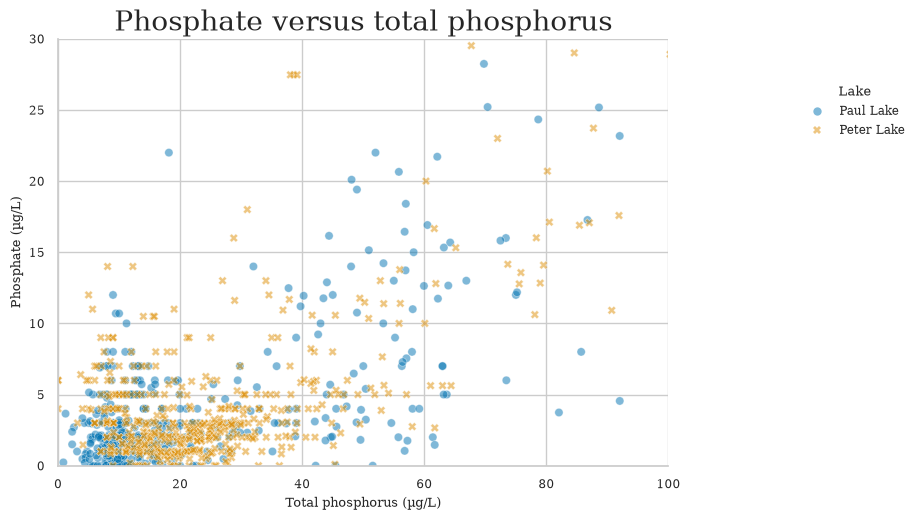

In [25]:
# 4. Create a scatterplot of PO4 vs TP
output_fldr = project_fldr / 'output'
output_fldr.mkdir(exist_ok=True)

g = sns.relplot(
    data=lakes,
    x='tp_ug',
    y='po4',
    kind='scatter',
    hue='lakename',
    style='lakename',
    alpha=0.5,
    height=5, aspect=1.4
)
g.set(
    title='Phosphate versus total phosphorus',
    xlabel='Total phosphorus (µg/L)',
    ylabel='Phosphate (µg/L)',
    xlim=(0, 100),
    ylim=(0, 30)
)
sns.move_legend(g, loc='upper left', title='Lake', bbox_to_anchor=(1.01, 0.9))
g.figure.savefig(output_fldr / 'A5_TP_vs_PO4_scatter.png', dpi=200, bbox_inches='tight')

#### 4-Challenge
* Re-construct your plot so that it includes a regression line (hint: `lmplot()`)
* Note that for the regression line to exclude extreme values, you'll have to filter the dataframe used in the plot; setting the x and y limits won't do that for you. 

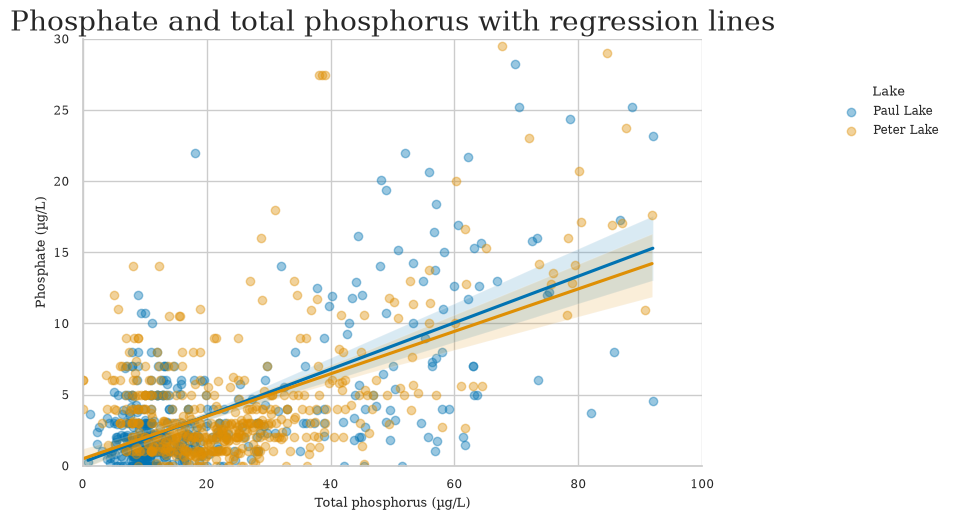

In [26]:
# 4-challenge
lake_fit = lakes[
    lakes['tp_ug'].between(0, 100) & lakes['po4'].between(0, 30)
]

g = sns.lmplot(
    data=lake_fit,
    x='tp_ug',
    y='po4',
    hue='lakename',
    scatter_kws={'alpha': 0.4},
    height=5, aspect=1.4
)
g.set(
    title='Phosphate and total phosphorus with regression lines',
    xlabel='Total phosphorus (µg/L)',
    ylabel='Phosphate (µg/L)',
    xlim=(0, 100),
    ylim=(0, 30)
)
sns.move_legend(g, loc='upper left', title='Lake', bbox_to_anchor=(1.01, 0.9))
g.figure.savefig(output_fldr / 'A5_TP_vs_PO4_regression.png', dpi=200, bbox_inches='tight')

### 5. Comparison of monthly trends of select variables across lakes
We are interested in comparing monthly trends in three lake variables: Total Nitrogren, Total Phosphorus, and Temperature, contrasting differences among the two lakes.
* 5.1 First, you'll need to "melt" your data so that all temperature, TP, and TN measures appear in a single column alongside a separate column that lists whether the row is temperature, TN, or TP record.
* 5.2 Construct a box plot of the 3 lake measurements such that
    - Months appear along the x-axis
    - Peter and Paul lake data are shown in different colors
    - The plots for temperature, TN, and TP are shown as separate facets, stacked vertically, and each have their own y-axis scale (hint: `sharey=False`).
    - Remove the individual plot titles and x-axis labels (hint: set to an empty string `""`).
    - Set the y-axis labels to indicate the plots of Temperature, Total Nitrogen, and Total Phosphorus. 

In [27]:
# 5.1 Melt the NTL LTR dataset so that Temperature, TN, and TP measures are consolidated in a single column
lake_long = lakes.melt(
    id_vars=['lakename', 'month_abb'],
    value_vars=['temperature_C', 'tn_ug', 'tp_ug'],
    var_name='measurement',
    value_name='value'
)
lake_long.head()

,lakename,month_abb,measurement,value
0,Paul Lake,May,temperature_C,14.5
1,Paul Lake,May,temperature_C,NaN
2,Paul Lake,May,temperature_C,NaN
3,Paul Lake,May,temperature_C,NaN
4,Paul Lake,May,temperature_C,14.5


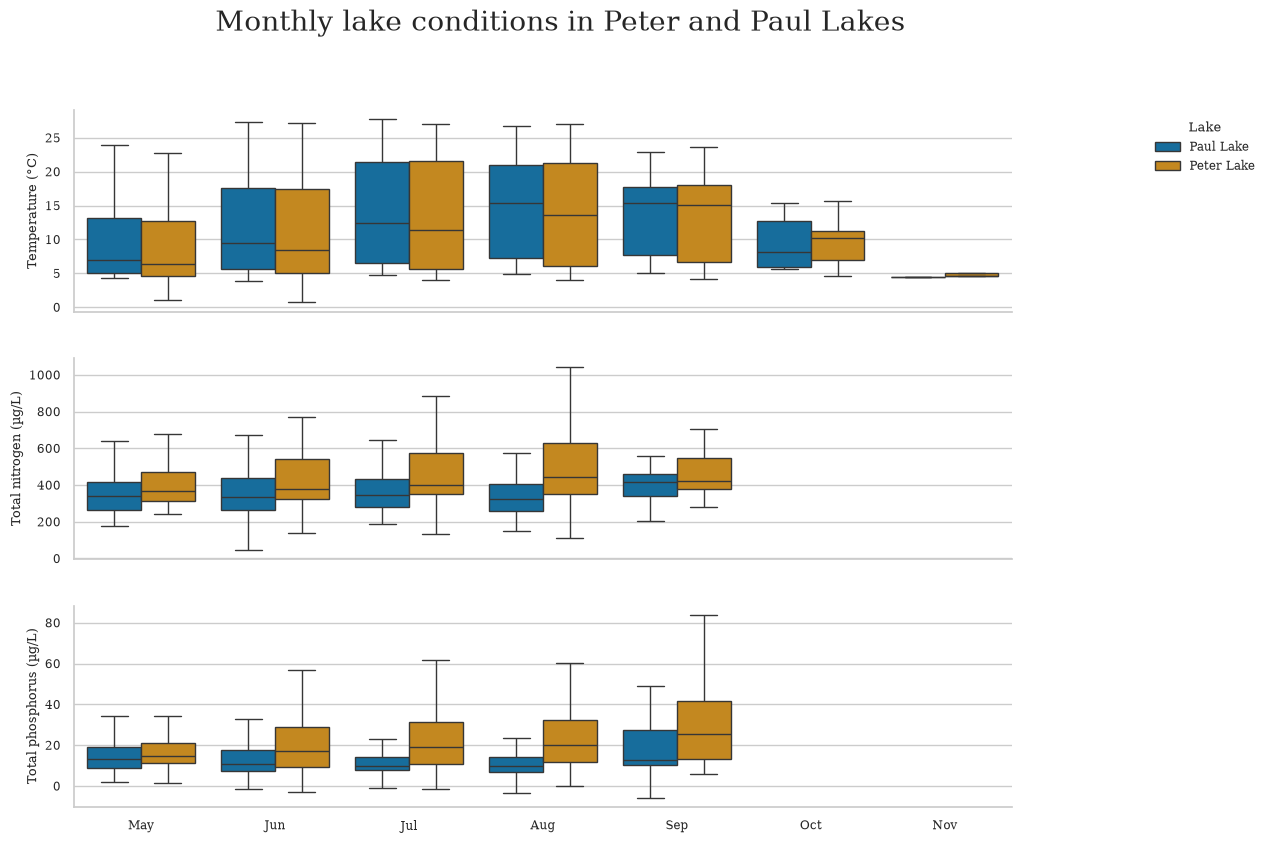

In [28]:
# 5.2 Create the faceted plot
g = sns.catplot(
    data=lake_long,
    x='month_abb',
    y='value',
    hue='lakename',
    col='measurement',
    col_order=['temperature_C', 'tn_ug', 'tp_ug'],
    col_wrap=1,
    order=calendar.month_abbr[5:12],
    kind='box',
    sharey=False,
    showfliers=False,
    height=2.8, aspect=3.7
)


# 5.3 Style the plot
g.set_titles('')
g.set_xlabels('')
g.axes[0].set(ylabel='Temperature (°C)')
g.axes[1].set(ylabel='Total nitrogen (µg/L)')
g.axes[2].set(ylabel='Total phosphorus (µg/L)')
g.figure.subplots_adjust(top=0.90, hspace=0.23)
g.figure.suptitle('Monthly lake conditions in Peter and Paul Lakes', fontsize=20, y=1.02)

# 5.4 Set the legend
sns.move_legend(g, loc='upper left', title='Lake', bbox_to_anchor=(1.01, 0.9))
g.figure.savefig(output_fldr / 'A5_monthly_lake_comparison.png', dpi=200, bbox_inches='tight')

#### ✅ Question
**What do you observe about the variables of interest over seasons and between lakes?**
> **Answer**:  
>  In the reconstructed dataset, water temperature goes up from May to late summer and then goes back down in October and November. Paul Lake is a little warmer than Peter Lake for most of May to September. The overall median temperature is 11.3 °C for Paul Lake and 10.2 °C for Peter Lake. Peter Lake usually has more total nitrogen and total phosphorus. Its median TN is 402 µg/L, compared to 340 µg/L in Paul Lake, and its median TP is 18.23 µg/L, compared to 10.5 µg/L. In Peter Lake, the monthly median TP goes up from about 15 µg/L in May to 26 µg/L in September, but in Paul Lake it stays around 10-13 µg/L. Most of the nutrient data were collected between May and September, so we can't really say anything about seasonal patterns for the whole year. Also, the original data include samples from different depths, so we can't really say anything about seasonal patterns for the whole year. Also, the original data include samples from different depths, so these comparisons only describe the data and don't show a controlled effect of the lake itself.

### 6. Dry mass of needles over time
We are curious how the amount of needles is changing from year to year, specifically how those trends might appear across different land cover types. To do that we'll explore a few visualizations. 

#### 6.1 Change in needle dry mass over time, single plot
* Plot a subset of the litter dataset by displaying only the "Needles" functional group in a single plot figure. 
* Plot the dry mass of needle litter by year, separating by NLCD class with a color aesthetic. (no need to adjust the name of each land use)
* Treat the years as categorical data in your selection of `displot()`, `catplot()`, or `relplot()` plotting functions. 
* Select a plotting function subplot type (e.g. "scatterplot" for relplot, "swarmplot" for catplot) that you feel best illustrates change over time of the needle dry mass from year to year to year for the different land cover types.
* Style your plot for professionalism and clarity.  Specifically:
    - Give your plot a title.
    - Label axes appropriately. ("Year" is an optional label, as it can be considered obvious.)
    - Title and place your legend to maximize clarity.
    - Ensure that your font sizes are appropriate. (Hint: adjust plot height and aspect.)
    - *You can use default cover type names, e.g. `shrubScrub`.*

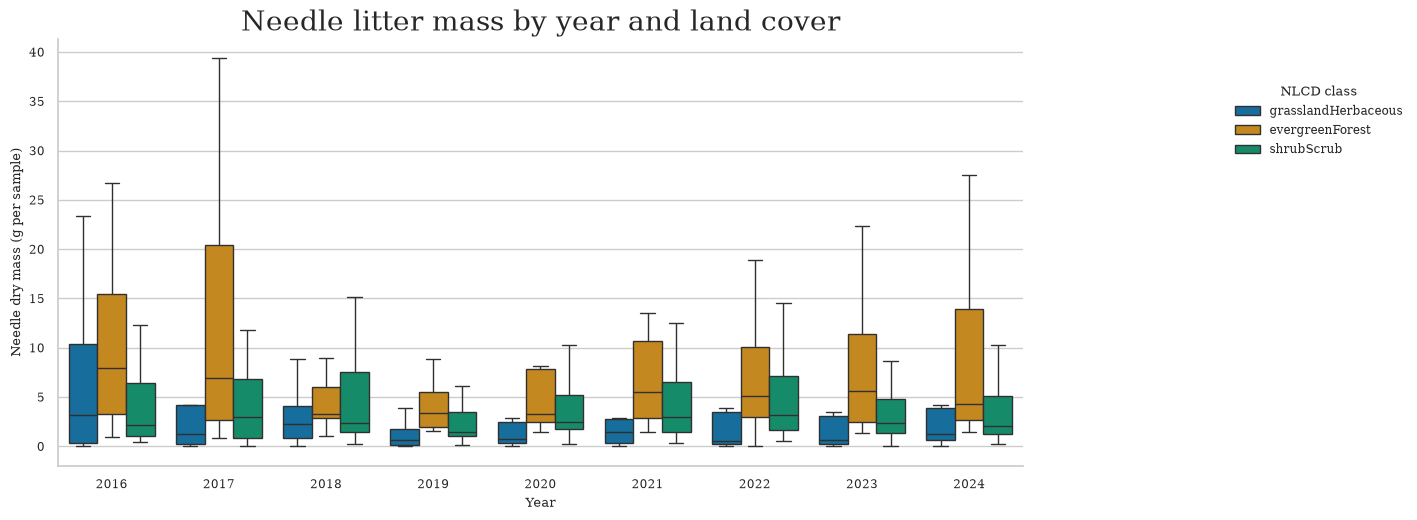

In [29]:
# 6. Plot the dry mass of needles over time, separated by NLCD cover type
needles = litter.loc[litter['functionalGroup'] == 'Needles']

g = sns.catplot(
    data=needles,
    x='year',
    y='dryMass',
    hue='nlcdClass',
    kind='box',
    showfliers=False,
    height=5, aspect=2.1
)
g.set(
    title='Needle litter mass by year and land cover',
    xlabel='Year',
    ylabel='Needle dry mass (g per sample)'
)
sns.move_legend(g, loc='upper left', title='NLCD class', bbox_to_anchor=(1.01, 0.9))
g.figure.savefig(output_fldr / 'A5_needle_mass_single.png', dpi=200, bbox_inches='tight')

#### 6.2 Change in needle dry mass over time, facet plot
* Recreate your plot above, but instead of a single plot, break your plot into 3 facets: one for each cover type. 
* You are welcome to explore different plot subtypes than the previous plot. 
* Decide whether you want to stack the facet plots vertically or horizontally based on how well it communicates differences in the trends and magnitude of leaf litter change over time across the different cover types. 
* As before, style your plot for professionalism and clarity. 

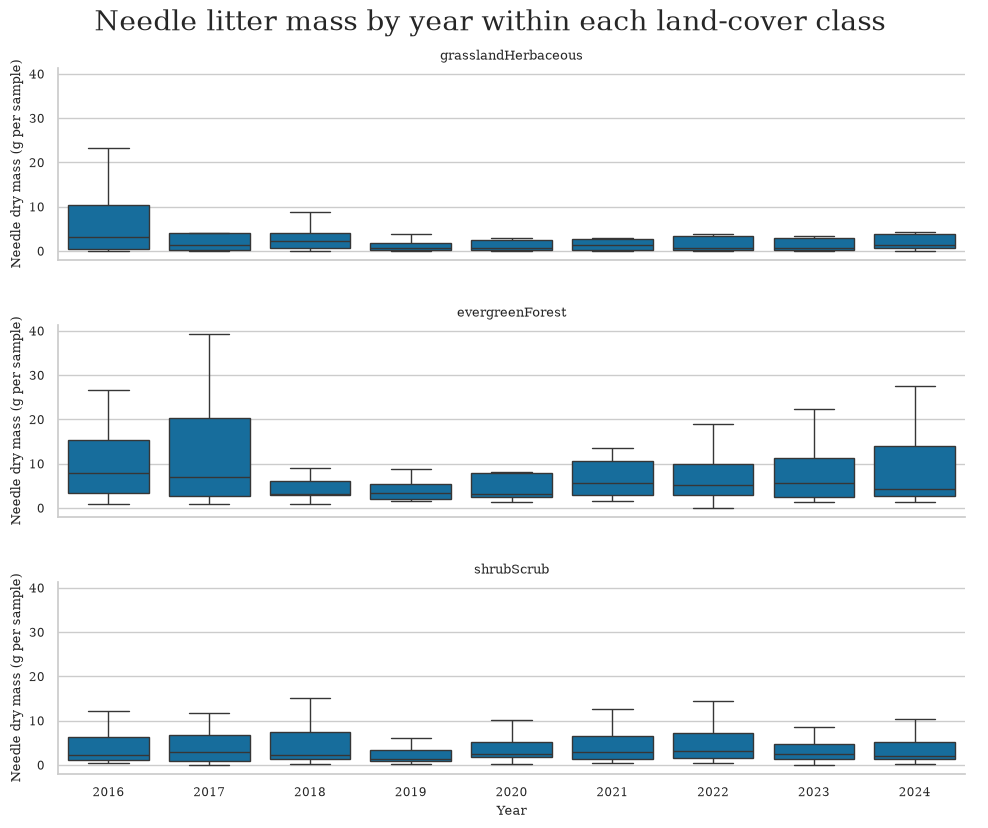

In [30]:
# 6.2 Plot the dry mass of needles over time, faceted by NLCD cover type
g = sns.catplot(
    data=needles,
    x='year',
    y='dryMass',
    col='nlcdClass',
    col_wrap=1,
    kind='box',
    showfliers=False,
    sharey=True,
    height=2.8, aspect=3.5
)
g.set(xlabel='Year', ylabel='Needle dry mass (g per sample)')
g.set_titles('{col_name}')
g.figure.subplots_adjust(top=0.91, hspace=0.34)
g.figure.suptitle('Needle litter mass by year within each land-cover class', fontsize=20)
g.figure.savefig(output_fldr / 'A5_needle_mass_facets.png', dpi=200, bbox_inches='tight')

#### ✅ Question
**Which of the two plots do you feel better reveals the pattern of needle dry mass over time? Why?**
> **Answer**: 
 Across years, forest consistently shows the highest median needle mass (4.38 g per sample), while grassland shows the lowest (1.26 g), and the faceted panels bring out this stable gap more clearly. If the main goal is to compare habitats directly within a single year, the combined plot offers a more compact view.
>  


#### ✅ Question
**Explain your choice of subplot in the plots above. What aspects of that subplot type led to your choice.**
> **Answer**:  
>  Since year is treated as a categorical variable and each year–cover combination includes several dry-mass measurements, I used catplot(kind="box"). Box plots display the median, interquartile range, and whiskers, so shifts in both typical mass and spread are easy to see. To keep the panels uncluttered, I suppressed the points lying outside the whiskers; as a result, these plots shouldn't be relied on to assess how large or how numerous the extreme observations are.